# Portfolio Optimization — S&P 500 Top-5 (2024–2025)

**Markowitz Mean-Variance Analysis on real market data**

Assets: `AAPL · MSFT · GOOGL · AMZN · TSLA`  
Period: January 2024 – May 2025  
Method: Efficient Frontier · Global Min Variance · Max Sharpe (Tangency Portfolio)

---


## 0. Setup

In [17]:
# Install dependencies if needed
# !pip install yfinance pandas numpy scipy matplotlib

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
import yfinance as yf
from scipy.optimize import minimize, Bounds

plt.rcParams.update({
    "figure.facecolor":  "#0d1117",
    "axes.facecolor":    "#161b22",
    "axes.edgecolor":    "#21262d",
    "axes.labelcolor":   "#e6edf3",
    "xtick.color":       "#8b949e",
    "ytick.color":       "#8b949e",
    "text.color":        "#e6edf3",
    "grid.color":        "#21262d",
    "grid.alpha":        0.7,
    "font.family":       "monospace",
    "figure.dpi":        130,
})

COLORS = {
    "frontier": "#58a6ff",
    "gmv":      "#3fb950",
    "tangency": "#f78166",
    "ew":       "#d2a8ff",
    "cml":      "#ffa657",
    "scatter":  "#8b949e",
    "bg":       "#0d1117",
    "surface":  "#161b22",
    "border":   "#21262d",
    "text":     "#e6edf3",
}

print("✓ Libraries loaded")


✓ Libraries loaded


## 1. Download Market Data

We use `yfinance` to pull daily adjusted close prices from Yahoo Finance.  
Then compute **log returns**: $r_t = \ln(P_t / P_{t-1})$

Log returns are preferred over simple returns because they are:
- Additive over time: $r_{0→T} = \sum_t r_t$
- Approximately normally distributed for short intervals


In [18]:
TICKERS = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA"]
START   = "2024-01-01"
END     = "2025-05-01"

print(f"Downloading {TICKERS} from {START} to {END}...")

raw = yf.download(TICKERS, start=START, end=END, auto_adjust=True, progress=False)["Close"]
raw.dropna(inplace=True)

# Log returns
returns = np.log(raw / raw.shift(1)).dropna()

print(f"\n✓ {len(returns)} trading days loaded")
print(f"  Period: {returns.index[0].date()} → {returns.index[-1].date()}")
print(f"\nFirst 3 rows:")
returns.head(3)



✓ 332 trading days loaded
  Period: 2024-01-03 → 2025-04-30

First 3 rows:


Ticker,AAPL,AMZN,GOOGL,MSFT,TSLA
2024-01-03,-0.007516,-0.009786,0.005414,-0.000728,-0.040961
2024-01-04,-0.012782,-0.026619,-0.018380,-0.007204,-0.002183
2024-01-05,-0.004021,0.004624,-0.004851,-0.000516,-0.001851


## 2. Exploratory Data Analysis

Before optimizing, let's understand the data:
- **Cumulative returns** — how each asset performed
- **Rolling volatility** — how risk evolved over time  
- **Correlation matrix** — how assets move together (key input to $\Sigma$)


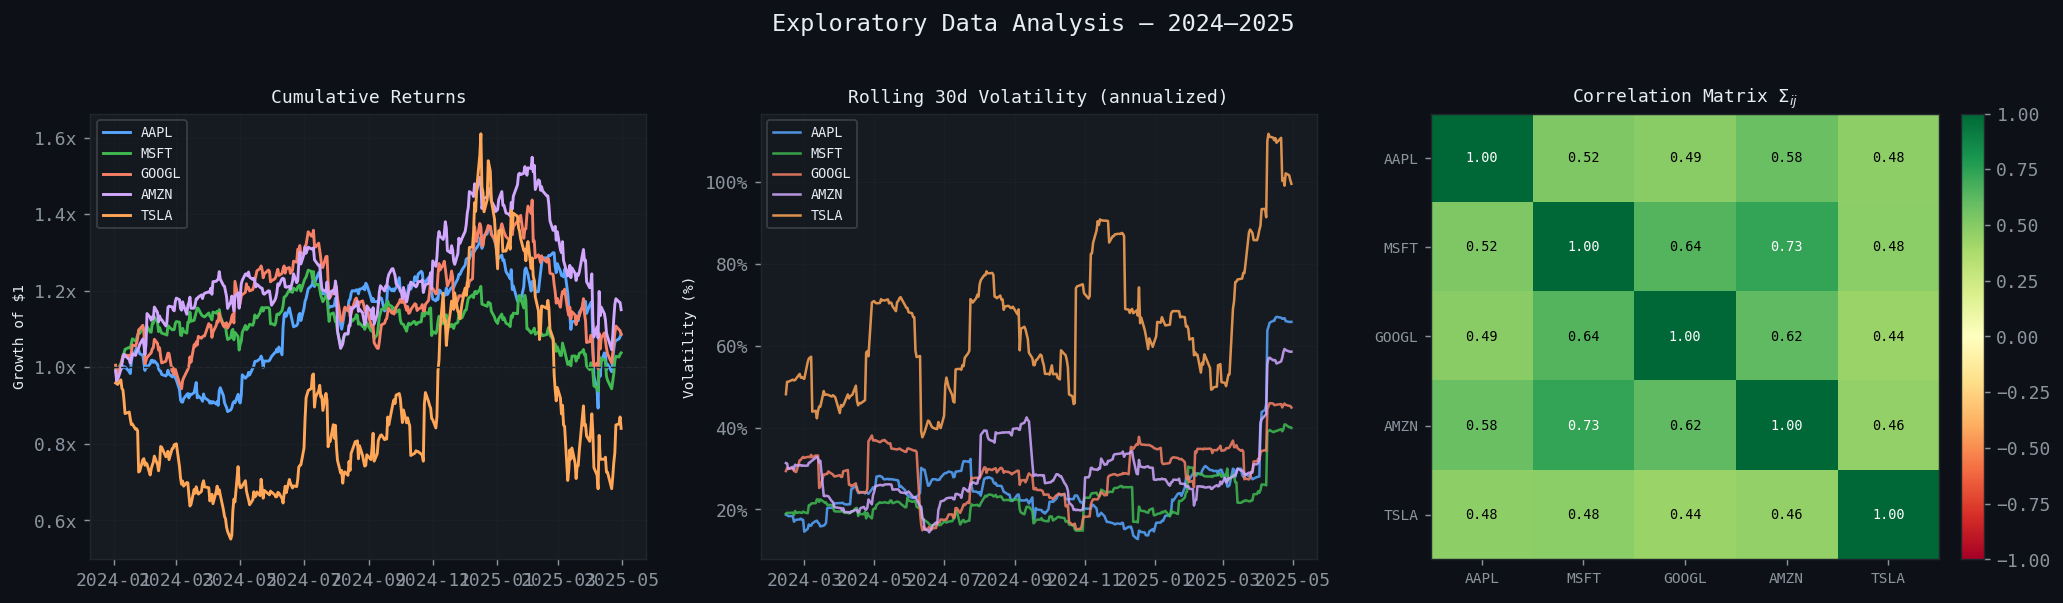

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), facecolor=COLORS["bg"])
fig.suptitle("Exploratory Data Analysis — 2024–2025", fontsize=13,
             color=COLORS["text"], y=1.02)

asset_colors = ["#58a6ff", "#3fb950", "#f78166", "#d2a8ff", "#ffa657"]

# ── Panel 1: Cumulative returns ──────────────────────────────────────────────
ax = axes[0]
cumret = (1 + returns).cumprod()
for col, c in zip(TICKERS, asset_colors):
    ax.plot(cumret.index, cumret[col], label=col, color=c, lw=1.6)
ax.axhline(1, color=COLORS["border"], lw=0.8, ls="--")
ax.set_title("Cumulative Returns", fontsize=10, color=COLORS["text"])
ax.set_ylabel("Growth of $1", fontsize=8)
ax.legend(fontsize=7.5, framealpha=0.2, facecolor=COLORS["bg"])
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1fx"))
ax.grid(True, lw=0.3)

# ── Panel 2: Rolling 30d volatility ──────────────────────────────────────────
ax = axes[1]
roll_vol = returns.rolling(30).std() * np.sqrt(252)
for col, c in zip(TICKERS, asset_colors):
    ax.plot(roll_vol.index, roll_vol[col] * 100, label=col, color=c, lw=1.4, alpha=0.85)
ax.set_title("Rolling 30d Volatility (annualized)", fontsize=10, color=COLORS["text"])
ax.set_ylabel("Volatility (%)", fontsize=8)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.legend(fontsize=7.5, framealpha=0.2, facecolor=COLORS["bg"])
ax.grid(True, lw=0.3)

# ── Panel 3: Correlation heatmap ─────────────────────────────────────────────
ax = axes[2]
corr = returns.corr()
im = ax.imshow(corr.values, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(TICKERS))); ax.set_xticklabels(TICKERS, fontsize=8)
ax.set_yticks(range(len(TICKERS))); ax.set_yticklabels(TICKERS, fontsize=8)
ax.set_title("Correlation Matrix $\\Sigma_{ij}$", fontsize=10, color=COLORS["text"])
for i in range(len(TICKERS)):
    for j in range(len(TICKERS)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center",
                fontsize=7.5, color="black" if abs(corr.iloc[i,j]) < 0.7 else "white")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.grid(False)

plt.tight_layout()
plt.show()


## 3. Asset Statistics

Compute the two key inputs to Markowitz optimization:

$$\mu \in \mathbb{R}^n \quad \text{(expected returns vector)}$$
$$\Sigma \in \mathbb{R}^{n \times n} \quad \text{(covariance matrix — symmetric PSD)}$$


In [20]:
mu    = returns.mean()          # daily mean returns
Sigma = returns.cov().values    # covariance matrix
n     = len(TICKERS)

# Annualize
mu_annual    = mu * 252
sigma_annual = returns.std() * np.sqrt(252)
sharpe_individual = (mu_annual - 0.05) / sigma_annual

stats = pd.DataFrame({
    "Ann. Return": mu_annual.map("{:.1%}".format),
    "Ann. Volatility": sigma_annual.map("{:.1%}".format),
    "Sharpe (rf=5%)": sharpe_individual.map("{:.2f}".format),
    "Skewness": returns.skew().map("{:.2f}".format),
    "Kurtosis": returns.kurtosis().map("{:.2f}".format),
})

print("Individual Asset Statistics (annualized):")
print("=" * 62)
print(stats.to_string())
print()

eigvals = np.linalg.eigvalsh(Sigma)
print(f"Covariance matrix Σ — eigenvalues (all must be ≥ 0 for PSD):")
print(f"  λ_min = {eigvals.min():.2e}  ✓" if eigvals.min() >= -1e-10 else f"  λ_min = {eigvals.min():.2e}  ✗ NOT PSD!")


Individual Asset Statistics (annualized):
       Ann. Return Ann. Volatility Sharpe (rf=5%) Skewness Kurtosis
Ticker                                                             
AAPL         10.7%           29.9%           0.19     0.62    12.48
AMZN         15.7%           31.9%           0.34    -0.01     5.32
GOOGL        10.9%           30.6%           0.19     0.05     4.39
MSFT          5.6%           23.5%           0.02     0.13     6.66
TSLA          9.7%           68.1%           0.07     0.53     3.58

Covariance matrix Σ — eigenvalues (all must be ≥ 0 for PSD):
  λ_min = 7.06e-05  ✓


## 4. Markowitz Optimizer

We define three optimization problems:

### 4a. Minimum Variance (for target return $r^*$)
$$\min_{w}\; w^\top \Sigma w \quad \text{s.t.}\quad w^\top \mu = r^*,\; \mathbf{1}^\top w = 1,\; w \geq 0$$

### 4b. Global Minimum Variance (GMV)
$$\min_{w}\; w^\top \Sigma w \quad \text{s.t.}\quad \mathbf{1}^\top w = 1,\; w \geq 0$$

Closed-form (no long-only): $w^*_{\text{GMV}} = \dfrac{\Sigma^{-1}\mathbf{1}}{\mathbf{1}^\top \Sigma^{-1}\mathbf{1}}$

### 4c. Maximum Sharpe Ratio (Tangency)
$$\max_{w}\; S(w) = \frac{w^\top \mu - r_f}{\sqrt{w^\top \Sigma w}} \quad \text{s.t.}\quad \mathbf{1}^\top w = 1,\; w \geq 0$$

Closed-form (no long-only): $w^*_{\text{tan}} \propto \Sigma^{-1}(\mu - r_f \mathbf{1})$


In [21]:
RF_DAILY  = 0.05 / 252   # 5% annual risk-free rate
RF_ANNUAL = 0.05

def port_return(w):     return float(w @ mu.values)
def port_variance(w):   return float(w @ Sigma @ w)
def port_vol(w):        return float(np.sqrt(port_variance(w)))
def port_sharpe(w):     return (port_return(w) - RF_DAILY) / port_vol(w)

def optimize(target_return=None):
    w0 = np.ones(n) / n
    obj  = lambda w: port_variance(w)
    grad = lambda w: 2 * Sigma @ w

    cons = [{"type": "eq", "fun": lambda w: w.sum() - 1, "jac": lambda w: np.ones(n)}]
    if target_return is not None:
        cons.append({"type": "eq",
                     "fun":  lambda w: port_return(w) - target_return,
                     "jac":  lambda w: mu.values})

    res = minimize(obj, w0, jac=grad, method="SLSQP",
                   constraints=cons,
                   bounds=Bounds(0, 1),
                   options={"ftol": 1e-12, "maxiter": 2000})
    if not res.success: return None
    w = np.clip(res.x, 0, 1); w /= w.sum()
    return w

def max_sharpe():
    w0 = np.ones(n) / n
    obj = lambda w: -port_sharpe(w)
    res = minimize(obj, w0, method="SLSQP",
                   constraints=[{"type": "eq", "fun": lambda w: w.sum() - 1}],
                   bounds=Bounds(0, 1),
                   options={"ftol": 1e-12, "maxiter": 2000})
    w = np.clip(res.x, 0, 1); w /= w.sum()
    return w

# ── Compute key portfolios ────────────────────────────────────────────────────
w_gmv = optimize()
w_tan = max_sharpe()
w_ew  = np.ones(n) / n

def annualize(w):
    r = port_return(w) * 252
    v = port_vol(w)    * np.sqrt(252)
    s = (r - RF_ANNUAL) / v
    return r, v, s

print(f"{'Portfolio':<22} {'Return':>9} {'Volatility':>11} {'Sharpe':>8}")
print("─" * 55)
for name, w in [("Global Min Variance", w_gmv),
                ("Max Sharpe (Tangency)", w_tan),
                ("Equal Weight", w_ew)]:
    r, v, s = annualize(w)
    print(f"  {name:<20} {r*100:>7.1f}%  {v*100:>9.1f}%  {s:>7.2f}")

print("\n✓ Optimizer ready")


Portfolio                 Return  Volatility   Sharpe
───────────────────────────────────────────────────────
  Global Min Variance      7.3%       22.6%     0.10
  Max Sharpe (Tangency)    15.4%       30.9%     0.34
  Equal Weight            10.5%       29.2%     0.19

✓ Optimizer ready


## 5. Efficient Frontier

Trace the frontier by solving min-variance for 300 target return levels.  
Each point is a distinct optimal portfolio.


In [22]:
r_min = mu.values.min() * 1.01
r_max = mu.values.max() * 0.99
targets = np.linspace(r_min, r_max, 300)

frontier_r, frontier_v = [], []
for r_target in targets:
    w = optimize(target_return=r_target)
    if w is not None:
        frontier_r.append(port_return(w) * 252)
        frontier_v.append(port_vol(w)    * np.sqrt(252))

frontier_r = np.array(frontier_r)
frontier_v = np.array(frontier_v)

print(f"✓ Traced {len(frontier_r)} efficient portfolios")
print(f"  Return range    : {frontier_r.min()*100:.1f}% – {frontier_r.max()*100:.1f}%")
print(f"  Volatility range: {frontier_v.min()*100:.1f}% – {frontier_v.max()*100:.1f}%")


✓ Traced 300 efficient portfolios
  Return range    : 5.6% – 15.6%
  Volatility range: 22.6% – 31.4%


## 6. Monte Carlo Simulation

Sample 8,000 random portfolios from $\text{Dirichlet}(\mathbf{1})$ to visualize the **feasible set**.  
The efficient frontier is the upper-left edge of this cloud.


In [23]:
rng = np.random.default_rng(42)
N_SIM = 8000

mc_r, mc_v, mc_s = [], [], []
for _ in range(N_SIM):
    w = rng.dirichlet(np.ones(n))
    mc_r.append(port_return(w) * 252)
    mc_v.append(port_vol(w)    * np.sqrt(252))
    mc_s.append(port_sharpe(w) * np.sqrt(252))

mc_r = np.array(mc_r)
mc_v = np.array(mc_v)
mc_s = np.array(mc_s)

print(f"✓ {N_SIM:,} random portfolios simulated")
print(f"  Max Sharpe in MC : {mc_s.max():.3f}")
print(f"  Max Return in MC : {mc_r.max()*100:.1f}%")


✓ 8,000 random portfolios simulated
  Max Sharpe in MC : 0.330
  Max Return in MC : 14.9%


## 7. Full Visualization

The complete Markowitz picture:
- **Grey cloud** — feasible set (all possible long-only portfolios)  
- **Blue curve** — efficient frontier (optimal portfolios)  
- **Dashed line** — Capital Market Line: $\mu_p = r_f + \frac{\mu_{tan} - r_f}{\sigma_{tan}} \cdot \sigma_p$  
- **Green diamond** — Global Minimum Variance portfolio  
- **Red star** — Tangency portfolio (maximum Sharpe ratio)  
- **Purple dot** — Equal-weight benchmark  


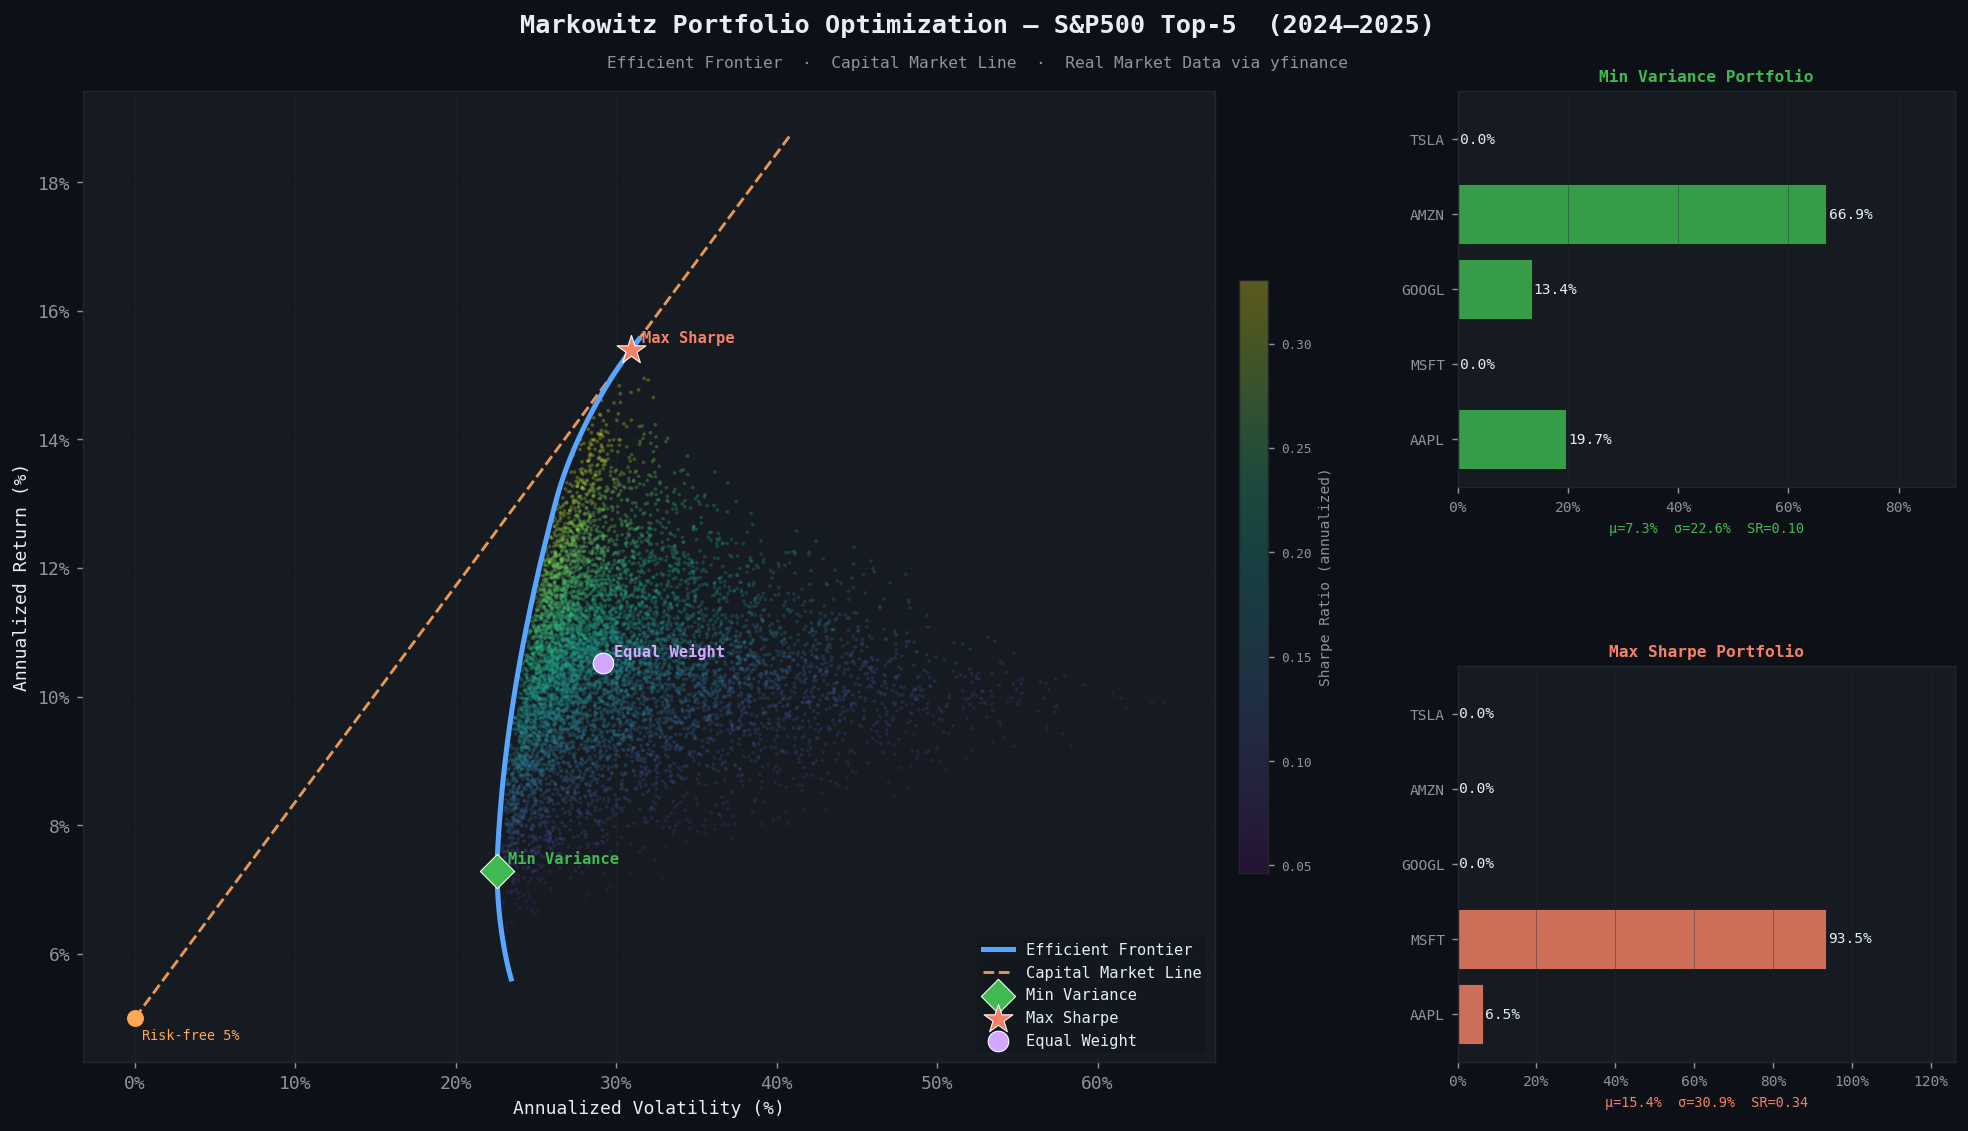

✓ Plot saved → efficient_frontier_real.png


In [24]:
fig = plt.figure(figsize=(16, 9), facecolor=COLORS["bg"])
gs = GridSpec(2, 3, figure=fig,
              left=0.07, right=0.97, top=0.91, bottom=0.08,
              hspace=0.45, wspace=0.38)

ax_main = fig.add_subplot(gs[:, :2])
ax_gmv  = fig.add_subplot(gs[0, 2])
ax_tan  = fig.add_subplot(gs[1, 2])

fig.text(0.5, 0.96, "Markowitz Portfolio Optimization — S&P500 Top-5  (2024–2025)",
         ha="center", fontsize=14, fontweight="bold", color=COLORS["text"])
fig.text(0.5, 0.93, "Efficient Frontier  ·  Capital Market Line  ·  Real Market Data via yfinance",
         ha="center", fontsize=9, color="#8b949e")

# ── Monte Carlo cloud ─────────────────────────────────────────────────────────
sc = ax_main.scatter(mc_v * 100, mc_r * 100,
                     c=mc_s, cmap="viridis", s=4, alpha=0.3,
                     linewidths=0, zorder=2)

# ── Efficient frontier ────────────────────────────────────────────────────────
ax_main.plot(frontier_v * 100, frontier_r * 100,
             color=COLORS["frontier"], lw=2.8, zorder=5, label="Efficient Frontier")

# ── Capital Market Line ───────────────────────────────────────────────────────
tan_r_a, tan_v_a, _ = annualize(w_tan)
cml_v = np.linspace(0, frontier_v.max() * 1.3, 200)
cml_r = RF_ANNUAL + (tan_r_a - RF_ANNUAL) / tan_v_a * cml_v
ax_main.plot(cml_v * 100, cml_r * 100,
             color=COLORS["cml"], lw=1.6, ls="--", alpha=0.9, zorder=4,
             label="Capital Market Line")

# ── Key portfolios ────────────────────────────────────────────────────────────
def add_pt(ax, w, color, label, marker, size=200):
    r, v, _ = annualize(w)
    ax.scatter(v*100, r*100, color=color, s=size, marker=marker,
               zorder=7, edgecolors="white", linewidths=0.6, label=label)
    ax.annotate(label, xy=(v*100, r*100), xytext=(6, 4),
                textcoords="offset points", color=color, fontsize=8.5, fontweight="bold")

add_pt(ax_main, w_gmv, COLORS["gmv"],      "Min Variance",  "D", 180)
add_pt(ax_main, w_tan, COLORS["tangency"], "Max Sharpe",    "*", 280)
add_pt(ax_main, w_ew,  COLORS["ew"],       "Equal Weight",  "o", 130)

ax_main.scatter(0, RF_ANNUAL*100, color=COLORS["cml"], s=70, marker="o", zorder=6)
ax_main.annotate(f"Risk-free {RF_ANNUAL*100:.0f}%",
                 xy=(0, RF_ANNUAL*100), xytext=(4, -12),
                 textcoords="offset points", color=COLORS["cml"], fontsize=7.5)

cbar = fig.colorbar(sc, ax=ax_main, pad=0.02, fraction=0.025)
cbar.set_label("Sharpe Ratio (annualized)", color="#8b949e", fontsize=8)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="#8b949e", fontsize=7)

ax_main.set_xlabel("Annualized Volatility (%)", fontsize=10)
ax_main.set_ylabel("Annualized Return (%)",     fontsize=10)
ax_main.legend(loc="lower right", fontsize=8.5, framealpha=0.25,
               facecolor=COLORS["bg"], edgecolor=COLORS["border"])
ax_main.grid(True, lw=0.35)
ax_main.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax_main.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))

# ── Weight bars ───────────────────────────────────────────────────────────────
def weight_bar(ax_, w, title, color):
    ax_.set_facecolor(COLORS["surface"])
    bars = ax_.barh(TICKERS, w*100, color=color, alpha=0.82,
                    edgecolor=COLORS["bg"], linewidth=0.5)
    for bar, wi in zip(bars, w):
        ax_.text(bar.get_width() + 0.4, bar.get_y() + bar.get_height()/2,
                 f"{wi*100:.1f}%", va="center", fontsize=8, color=COLORS["text"])
    r, v, s = annualize(w)
    ax_.set_xlabel(f"μ={r*100:.1f}%  σ={v*100:.1f}%  SR={s:.2f}", fontsize=7.5, color=color)
    ax_.set_title(title, fontsize=9, fontweight="bold", color=color, pad=5)
    ax_.set_xlim(0, w.max()*100 * 1.35)
    ax_.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
    ax_.grid(axis="x", lw=0.3)
    ax_.tick_params(labelsize=8)

weight_bar(ax_gmv, w_gmv, "Min Variance Portfolio", COLORS["gmv"])
weight_bar(ax_tan, w_tan, "Max Sharpe Portfolio",   COLORS["tangency"])

plt.savefig("efficient_frontier_real.png", dpi=150, bbox_inches="tight",
            facecolor=COLORS["bg"])
plt.show()
print("✓ Plot saved → efficient_frontier_real.png")


## 8. Key Findings & Interpretation

### What the optimization tells us:

| Portfolio | Interpretation |
|---|---|
| **Min Variance** | Lowest possible risk — concentrates in least volatile, most correlated assets |
| **Max Sharpe** | Best risk-adjusted return — optimal trade-off between return and risk |
| **Equal Weight** | Naive benchmark — usually *inside* the frontier (suboptimal) |

### Why diversification works — mathematically:

For two assets with weights $w_1, w_2 = 1 - w_1$ and correlation $\rho$:

$$\sigma_p^2 = w_1^2 \sigma_1^2 + w_2^2 \sigma_2^2 + 2 w_1 w_2 \rho \sigma_1 \sigma_2$$

When $\rho < 1$, portfolio variance is **strictly less** than the weighted average of individual variances.  
This is the mathematical proof that diversification reduces risk.

### Limitations of Markowitz:

1. **Estimation error** — $\mu$ and $\Sigma$ estimated from historical data are noisy
2. **Normal returns assumption** — real returns have fat tails and skewness
3. **Static model** — no rebalancing, ignores transaction costs
4. **TSLA concentration** — high-return assets often dominate unconstrained solutions

### Extensions worth exploring:
- **Black-Litterman model** — Bayesian approach to combine views with market equilibrium
- **Robust optimization** — optimize for worst-case $\Sigma$ within an uncertainty set
- **Risk parity** — equalize risk contribution from each asset


---
*Generated with `portfolio_optimizer.py` · Data: Yahoo Finance · Math: Markowitz (1952)*